# IMPORT PART

In [ ]:
import matplotlib.pyplot as plt
import random
import torch
import sys
sys.path.append('../src')
from dataset import train_raw
from augmentations import CIFAR_MEAN, CIFAR_STD
from augmentations import transform_exp1, transform_exp2, transform_exp3, transform_exp4, transform_exp5, transform_exp6, transform_exp7, transform_exp8

Files already downloaded and verified


d:\Deep Learning Project\venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


# VISUALIZATION
## POSITIVE PAIR VISUALIZATION [ ORIGINAL + VIEW A + VIEW B ]

In [2]:
def show_positive_pairs(transform, title, n=2):
    """
    Visualizes the stochastic nature of the augmentation pipeline by comparing 
    the original image with its corresponding generated positive pairs.
    """
    # Initialize a grid to display original images alongside two augmented views.
    fig, axes = plt.subplots(n, 3, figsize=(9, 3 * n))
    
    # Broadcastable tensors for de-normalization to revert the data back to its 
    # original pixel intensity range for accurate visualization.
    mean = torch.tensor(CIFAR_MEAN).view(3, 1, 1)
    std = torch.tensor(CIFAR_STD).view(3, 1, 1)

    for i in range(n):
        # Randomly sample an image from the raw dataset to ensure unbiased visualization.
        img, _ = train_raw[random.randint(0, len(train_raw)-1)]

        # Apply the stochastic transformation twice to produce distinct views 
        # (simulating the contrastive learning input).
        view1 = transform(img)
        view2 = transform(img)

        # Plotting the raw input image as a baseline reference.
        axes[i, 0].imshow(img)
        axes[i, 0].set_title("Original Image")
        axes[i, 0].axis("off")
  
        # De-normalization process: Reverses the standardization applied by T.Normalize.
        # Required for correct RGB color rendering in Matplotlib.  
        view1_denorm = view1 * std + mean
        view2_denorm = view2 * std + mean

        # Visualize 'View A' after re-arranging dimensions to (H, W, C) and clipping.
        axes[i, 1].imshow(view1_denorm.permute(1, 2, 0).clip(0, 1))
        axes[i, 1].set_title("Positive View A")
        axes[i, 1].axis("off")
        
        # Visualize 'View B' to demonstrate the variance within the same positive pair.
        axes[i, 2].imshow(view2_denorm.permute(1, 2, 0).clip(0, 1))
        axes[i, 2].set_title("Positive View B")
        axes[i, 2].axis("off")

    # Final layout adjustments for high-quality figure reporting.
    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

# Qualitative Analysis & Visualization of Augmentation Experiments

We execute the visualization function for each experiment to verify the 
visual impact of the combined transformations. This step ensures that 
the augmented views remain semantically coherent despite high variance.

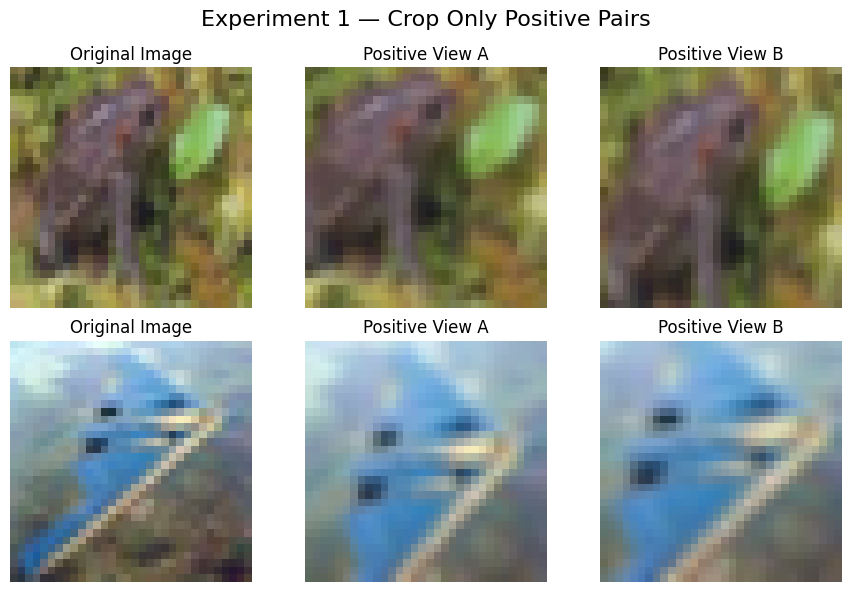

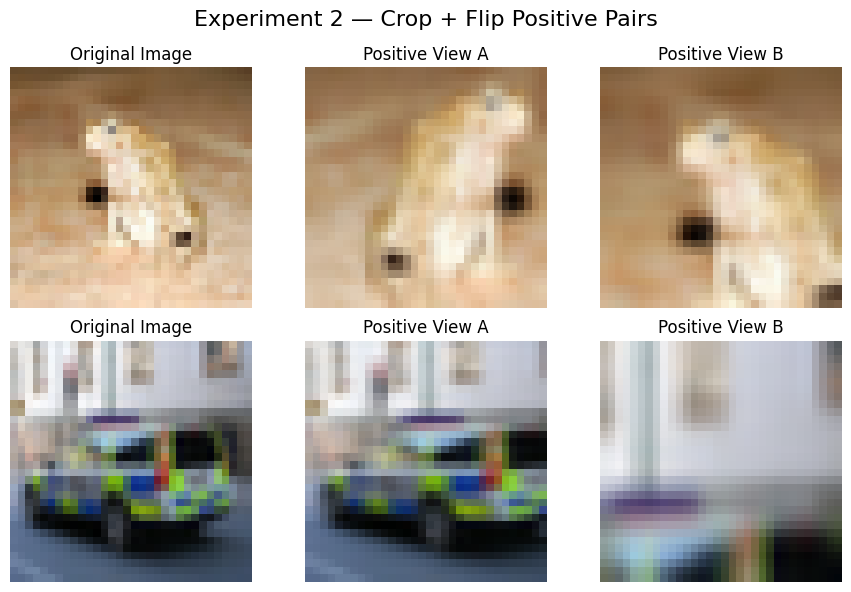

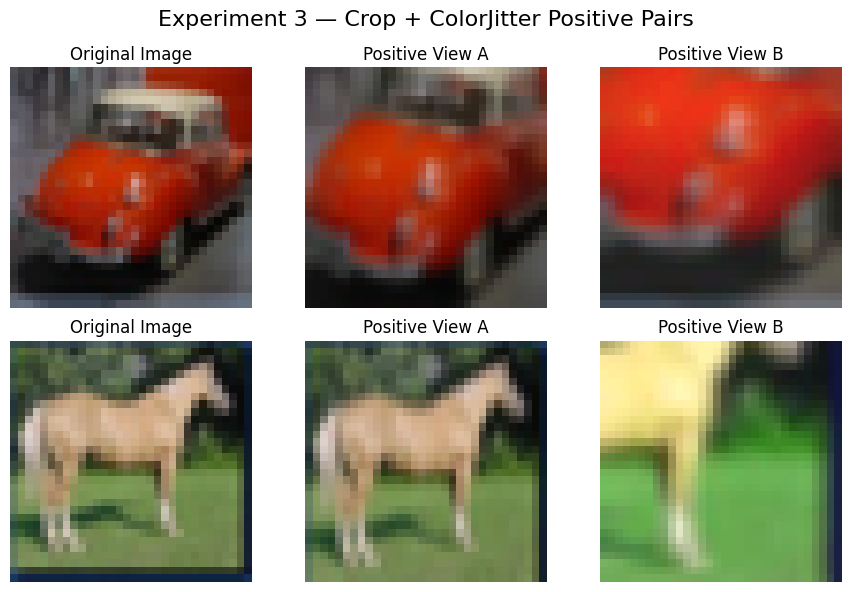

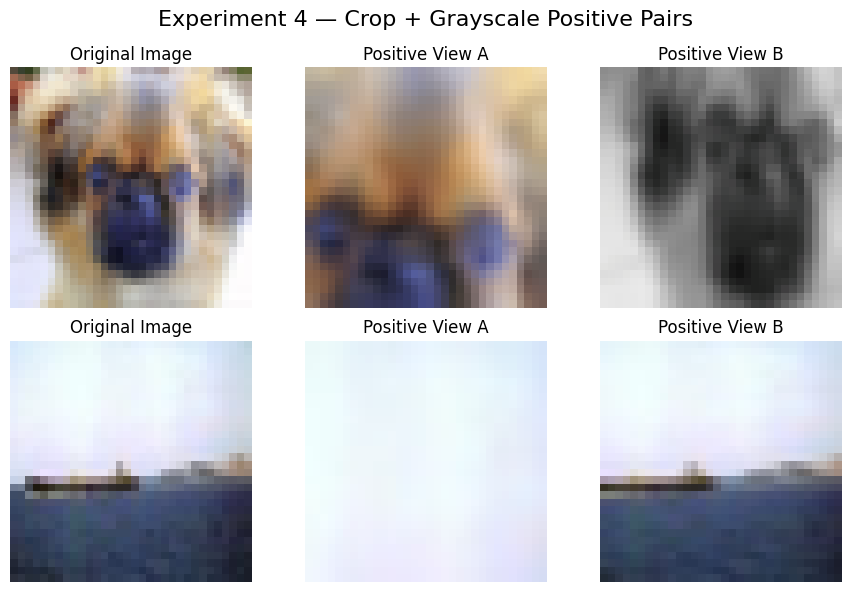

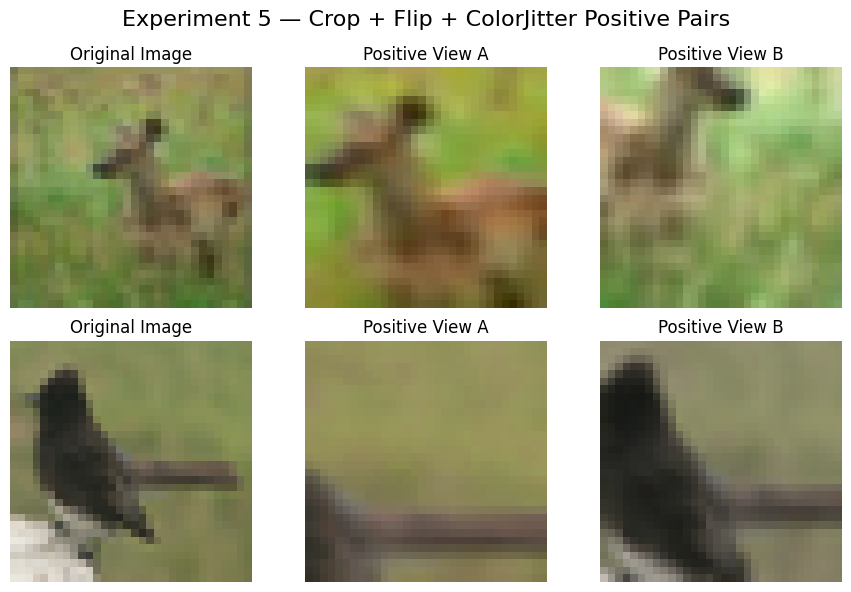

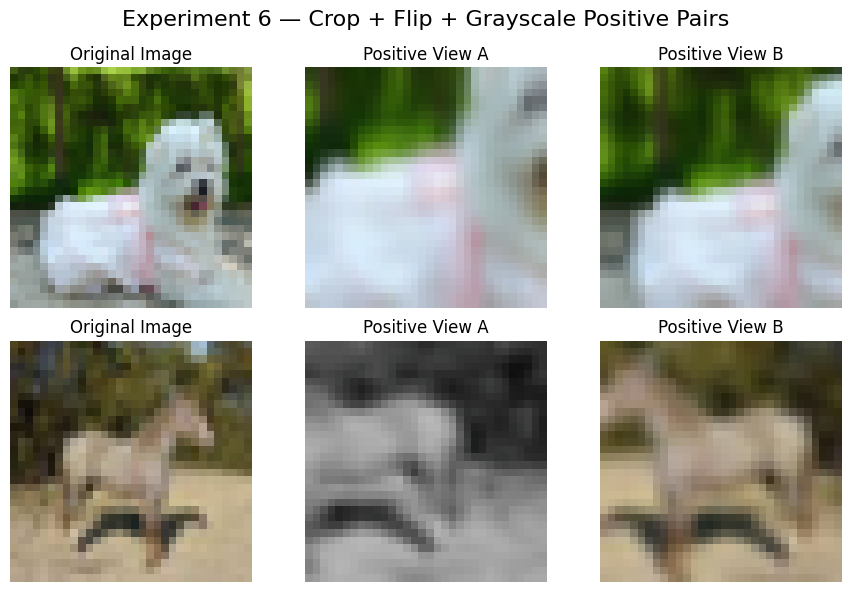

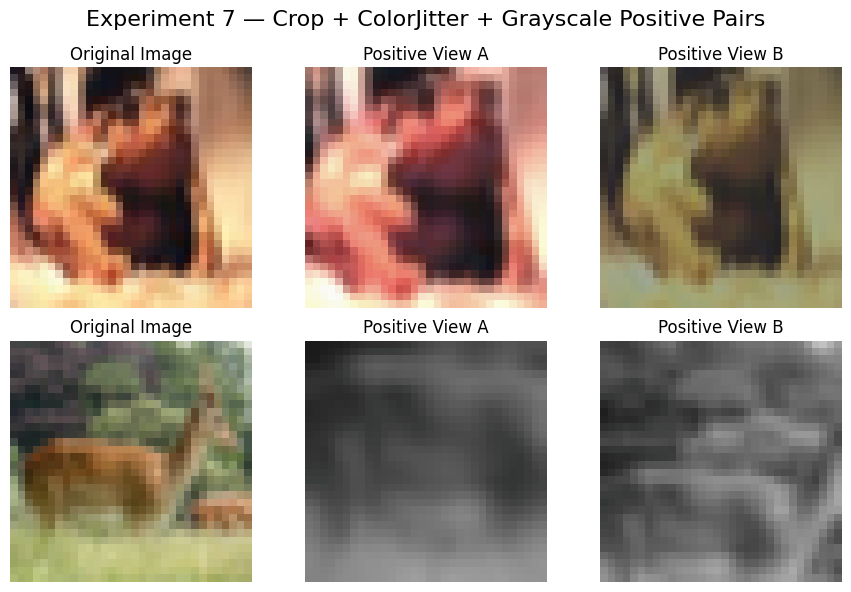

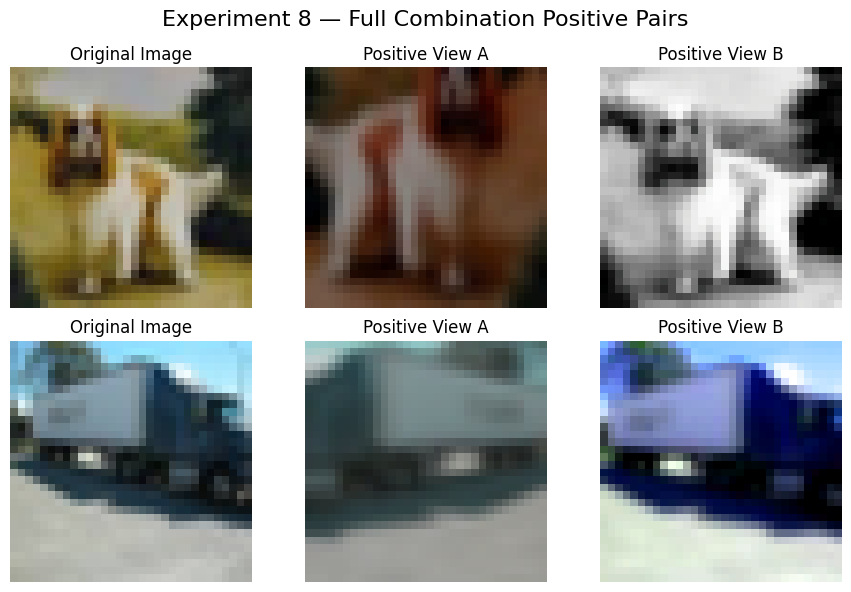

In [3]:
# EXP 1: Baseline spatial variance testing.
show_positive_pairs(
    transform_exp1,
    "Experiment 1 — Crop Only Positive Pairs"
)

# EXP 2: Assessing the influence of horizontal symmetry on spatial features.
show_positive_pairs(
    transform_exp2,
    "Experiment 2 — Crop + Flip Positive Pairs"
)

# EXP 3: Evaluating photometric distortion through aggressive color jittering.
show_positive_pairs(
    transform_exp3,
    "Experiment 3 — Crop + ColorJitter Positive Pairs"
)


# EXP 4: Investigating the removal of chromatic cues for shape-based learning.
show_positive_pairs(
    transform_exp4,
    "Experiment 4 — Crop + Grayscale Positive Pairs"
)


# EXP 5: Testing the interaction between geometric flipping and color noise.
show_positive_pairs(
    transform_exp5,
    "Experiment 5 — Crop + Flip + ColorJitter Positive Pairs"
)


# EXP 6: Combining geometric variance with complete chromatic information loss.
show_positive_pairs(
    transform_exp6,
    "Experiment 6 — Crop + Flip + Grayscale Positive Pairs"
)


# EXP 7: Evaluating heavy photometric suite without geometric symmetry.
show_positive_pairs(
    transform_exp7,
    "Experiment 7 — Crop + ColorJitter + Grayscale Positive Pairs"
)


# EXP 8: Final validation of the holistic SimCLR augmentation policy.
show_positive_pairs(
    transform_exp8,
    "Experiment 8 — Full Combination Positive Pairs"
)